# 🔬 2강. 단백체 데이터로 암 환자를 이해하다
## 섹션 1: 데이터 전처리와 환자군 분류

---

## 오늘의 스토리

> 간암 환자 50명의 종양 조직에서 단백질 발현을 측정했습니다.  
> 이 데이터로 **환자들을 그룹으로 나누고**, 각 그룹의 특성을 파악해봅니다.

```
원시 단백체 데이터
      ↓  결측값 처리
      ↓  정규화
      ↓  PCA (데이터 구조 파악)
      ↓  Clustering
환자군 분류 완료
```

| 단계 | 하는 일 | 왜 필요한가 |
|------|---------|------------|
| 결측값 처리 | 빈 값 채우기 | 측정 안 된 단백질 처리 |
| 정규화 | 값 범위 통일 | 환자마다 측정 총량이 다름 |
| PCA | 차원 축소 | 수천 개 단백질 → 2D로 요약 |
| Clustering | 그룹 나누기 | 비슷한 환자끼리 묶기 |

In [1]:
# ======================================
# 📦 라이브러리 불러오기
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import os

# scikit-learn: 머신러닝 도구 (PCA, Clustering)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ttest_ind

# 한글 폰트 설정
import matplotlib.font_manager as fm
NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(NANUM_PATH):
    fm.fontManager.addfont(NANUM_PATH)
    plt.rcParams['font.family'] = 'NanumGothic'
else:
    os.system('sudo apt-get update && sudo apt-get install -y fonts-nanum > /dev/null 2>&1')
    os.system('rm -rf ~/.cache/matplotlib')
    if os.path.exists(NANUM_PATH):
        fm.fontManager.addfont(NANUM_PATH)
        plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

np.random.seed(42)
print('✅ 준비 완료!')

✅ 준비 완료!


---
## 📊 1-1. 단백체 데이터 구조 이해

단백체 분석 결과는 보통 이런 형태의 표로 나옵니다:

```
           환자1    환자2    환자3   ...  환자50
단백질A     2.31     1.45     NaN   ...   3.21
단백질B     0.87     2.11     1.93  ...   0.54
단백질C     NaN      1.23     2.45  ...   1.87
...
단백질5000  1.45     NaN      0.98  ...   2.34
```

- **행(row)**: 단백질 (gene name으로 표시)
- **열(column)**: 환자 샘플
- **값**: 단백질 발현량 (log2 변환된 LFQ intensity)
- **NaN**: 그 환자에서 해당 단백질이 검출되지 않음

In [3]:
# ======================================
# 🧬 시뮬레이션 데이터 생성
# 실제 간암 단백체 데이터와 유사한 구조로 만듭니다.
# 환자 50명, 단백질 500개
# 실제 연구에서는 수천~수만 개의 단백질을 다룹니다.
# ======================================

N_PATIENTS  = 50   # 환자 수
N_PROTEINS  = 500  # 단백질 수

# --------------------------------------------------
# 환자를 3개 그룹으로 나눠서 생성
# (나중에 clustering이 이걸 찾아낼 수 있는지 확인)
# 그룹 A (20명): 대사 이상 주도형
# 그룹 B (20명): 증식 주도형
# 그룹 C (10명): 면역 활성형
# --------------------------------------------------

group_labels = ['A'] * 20 + ['B'] * 20 + ['C'] * 10
patient_ids  = [f'HCC_{i+1:03d}' for i in range(N_PATIENTS)]
protein_ids  = [f'Protein_{i+1:04d}' for i in range(N_PROTEINS)]

# 기본 발현 행렬 (정규분포)
expr = np.random.normal(loc=20, scale=3, size=(N_PROTEINS, N_PATIENTS))

# 그룹별 특징적 단백질 발현 추가
# 그룹 A: 대사 관련 단백질 100개 높게 발현
expr[:100, :20] += np.random.normal(4, 0.5, (100, 20))

# 그룹 B: 세포증식 관련 단백질 100개 높게 발현
expr[100:200, 20:40] += np.random.normal(5, 0.5, (100, 20))

# 그룹 C: 면역 관련 단백질 100개 높게 발현
expr[200:300, 40:] += np.random.normal(6, 0.5, (100, 10))

# 결측값 추가 (실제 데이터에서는 약 20~30% 결측)
missing_mask = np.random.random(size=expr.shape) < 0.20
expr[missing_mask] = np.nan

# DataFrame으로 변환
df_raw = pd.DataFrame(expr, index=protein_ids, columns=patient_ids)

# 환자 메타데이터
df_meta = pd.DataFrame({
    'Patient':    patient_ids,
    'Group':      group_labels,
    'Age':        np.random.randint(45, 75, N_PATIENTS),
    'Stage':      np.random.choice(['I', 'II', 'III', 'IV'], N_PATIENTS, p=[0.2, 0.3, 0.3, 0.2]),
    'Survival_month': np.concatenate([
        np.random.normal(48, 10, 20),  # 그룹 A: 비교적 좋음
        np.random.normal(30, 8,  20),  # 그룹 B: 중간
        np.random.normal(18, 6,  10),  # 그룹 C: 나쁨
    ]).clip(3, 72)
}).set_index('Patient')

print(f'데이터 크기: {df_raw.shape[0]}개 단백질 × {df_raw.shape[1]}명 환자')
print(f'결측값 비율: {df_raw.isna().sum().sum() / df_raw.size * 100:.1f}%')
print()
print('처음 5개 단백질, 5명 환자 데이터:')
print(df_raw.iloc[:5, :5].round(2))

데이터 크기: 500개 단백질 × 50명 환자
결측값 비율: 20.3%

처음 5개 단백질, 5명 환자 데이터:
              HCC_001  HCC_002  HCC_003  HCC_004  HCC_005
Protein_0001    22.74      NaN    21.73    28.57    23.73
Protein_0002    27.66    20.00    15.24    30.02    25.80
Protein_0003      NaN    27.58    31.37    17.82    23.90
Protein_0004    22.49    22.83    22.98      NaN    23.04
Protein_0005      NaN    27.98    21.19    29.15    22.49


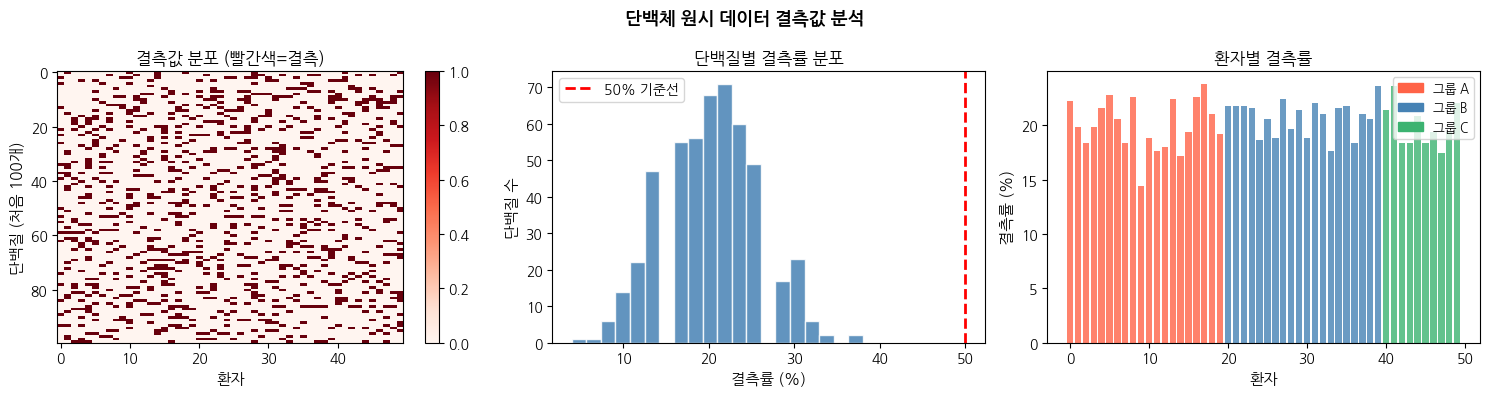

▶ 결측률 50% 초과 단백질: 0개 → 분석에서 제외 예정


In [4]:
# ======================================
# 📊 결측값 분포 시각화
# 어떤 단백질/환자에 결측이 많은지 파악
# ======================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 왼쪽: 결측값 히트맵 (단백질 100개만)
missing_map = df_raw.iloc[:100, :].isna().astype(int)
im = axes[0].imshow(missing_map, aspect='auto', cmap='Reds', interpolation='none')
axes[0].set_xlabel('환자', fontsize=11)
axes[0].set_ylabel('단백질 (처음 100개)', fontsize=11)
axes[0].set_title('결측값 분포 (빨간색=결측)', fontsize=12)
plt.colorbar(im, ax=axes[0])

# 가운데: 단백질별 결측률 분포
protein_missing_rate = df_raw.isna().mean(axis=1) * 100
axes[1].hist(protein_missing_rate, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(50, color='red', linestyle='--', linewidth=2, label='50% 기준선')
axes[1].set_xlabel('결측률 (%)', fontsize=11)
axes[1].set_ylabel('단백질 수', fontsize=11)
axes[1].set_title('단백질별 결측률 분포', fontsize=12)
axes[1].legend(fontsize=10)

# 오른쪽: 환자별 결측률
patient_missing_rate = df_raw.isna().mean(axis=0) * 100
axes[2].bar(range(N_PATIENTS), patient_missing_rate,
            color=['tomato' if g=='A' else 'steelblue' if g=='B' else 'mediumseagreen'
                   for g in group_labels], alpha=0.8)
axes[2].set_xlabel('환자', fontsize=11)
axes[2].set_ylabel('결측률 (%)', fontsize=11)
axes[2].set_title('환자별 결측률', fontsize=12)

# 범례
patches = [mpatches.Patch(color='tomato', label='그룹 A'),
           mpatches.Patch(color='steelblue', label='그룹 B'),
           mpatches.Patch(color='mediumseagreen', label='그룹 C')]
axes[2].legend(handles=patches, fontsize=9)

plt.suptitle('단백체 원시 데이터 결측값 분석', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_high_missing = (protein_missing_rate > 50).sum()
print(f'▶ 결측률 50% 초과 단백질: {n_high_missing}개 → 분석에서 제외 예정')

---
## 🧹 1-2. 데이터 전처리

### 전처리 순서

```
1. 결측률 높은 단백질 제거 (>50% missing)
2. 남은 결측값 imputation (중앙값으로 채우기)
3. 정규화 (각 환자의 발현값을 표준화)
```

### 왜 정규화가 필요한가?

환자마다 조직 양, 단백질 추출 효율이 달라서  
**같은 단백질도 환자마다 절대값이 다를 수 있습니다.**  
정규화로 이 기술적 차이를 제거합니다.

In [ ]:
# ======================================
# 🧹 전처리 파이프라인
# ======================================

print('=== 전처리 시작 ===')
print(f'원시 데이터: {df_raw.shape[0]}개 단백질 × {df_raw.shape[1]}명 환자')

# 1단계: 결측률 50% 초과 단백질 제거
protein_missing = df_raw.isna().mean(axis=1)
df_filtered = df_raw[protein_missing <= 0.5].copy()
print(f'\n[1단계] 결측률 >50% 단백질 제거: {df_raw.shape[0] - df_filtered.shape[0]}개 제거')
print(f'        → {df_filtered.shape[0]}개 단백질 남음')

# 2단계: 결측값 imputation (단백질별 중앙값으로 채우기)
# 실제 연구에서는 MinProb, KNN 등 더 정교한 방법을 씁니다.
df_imputed = df_filtered.copy()
for protein in df_imputed.index:
    median_val = df_imputed.loc[protein].median()
    df_imputed.loc[protein] = df_imputed.loc[protein].fillna(median_val)

print(f'\n[2단계] 결측값 imputation (중앙값 대체)')
print(f'        남은 결측값: {df_imputed.isna().sum().sum()}개')

# 3단계: Z-score 정규화 (단백질 기준)
# 각 단백질의 평균=0, 표준편차=1로 변환
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(df_imputed.T).T  # 단백질 기준 정규화
df_scaled = pd.DataFrame(expr_scaled, index=df_imputed.index, columns=df_imputed.columns)

print(f'\n[3단계] Z-score 정규화 완료')
print(f'        발현값 범위: {expr_scaled.min():.2f} ~ {expr_scaled.max():.2f}')
print(f'\n=== 전처리 완료: {df_scaled.shape[0]}개 단백질 × {df_scaled.shape[1]}명 환자 ===' )

In [ ]:
# ======================================
# 📊 정규화 전/후 비교 시각화
# ======================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 정규화 전: 환자별 발현값 분포
for i in range(0, N_PATIENTS, 5):  # 10명만 표시
    patient = patient_ids[i]
    color = 'tomato' if group_labels[i]=='A' else 'steelblue' if group_labels[i]=='B' else 'mediumseagreen'
    data = df_imputed[patient].dropna()
    axes[0].hist(data, bins=30, alpha=0.3, color=color, density=True)

axes[0].set_xlabel('발현값 (log2 intensity)', fontsize=11)
axes[0].set_ylabel('밀도', fontsize=11)
axes[0].set_title('정규화 전: 환자별 발현값 분포', fontsize=12)

# 정규화 후
for i in range(0, N_PATIENTS, 5):
    patient = patient_ids[i]
    color = 'tomato' if group_labels[i]=='A' else 'steelblue' if group_labels[i]=='B' else 'mediumseagreen'
    data = df_scaled[patient].dropna()
    axes[1].hist(data, bins=30, alpha=0.3, color=color, density=True)

axes[1].set_xlabel('Z-score', fontsize=11)
axes[1].set_ylabel('밀도', fontsize=11)
axes[1].set_title('정규화 후: 환자별 발현값 분포', fontsize=12)

# 범례
patches = [mpatches.Patch(color='tomato', label='그룹 A'),
           mpatches.Patch(color='steelblue', label='그룹 B'),
           mpatches.Patch(color='mediumseagreen', label='그룹 C')]
axes[1].legend(handles=patches, fontsize=10)

plt.suptitle('정규화 전/후 비교: 환자 간 분포가 통일됩니다', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 정규화 후 모든 환자의 분포가 비슷해졌습니다')
print('▶ 이제 환자 간 단백질 발현 비교가 의미있어집니다')

---
## 🔍 1-3. PCA: 데이터 구조 파악

### PCA란?

500개 단백질의 발현값 → **2개 숫자(PC1, PC2)** 로 요약합니다.

```
500차원 공간의 환자 데이터
        ↓ PCA
2차원 평면에 점으로 표시
```

> 💡 비슷한 단백질 발현 패턴을 가진 환자들은 **PCA 그래프에서 가까이** 모입니다.

In [ ]:
# ======================================
# 🔍 PCA 수행
# ======================================

# PCA 수행 (환자 기준: 행=환자, 열=단백질)
X = df_scaled.T.values  # shape: (50 환자, 500 단백질)

pca = PCA(n_components=10)  # 10개 주성분 계산
X_pca = pca.fit_transform(X)

# 설명력 확인
explained_var = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Scree plot (각 PC가 얼마나 설명하는지)
axes[0].bar(range(1, 11), explained_var, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, 11), np.cumsum(explained_var), 'ro-', linewidth=2, label='누적 설명력')
axes[0].axhline(80, color='gray', linestyle='--', alpha=0.5, label='80% 기준선')
axes[0].set_xlabel('주성분 (PC)', fontsize=11)
axes[0].set_ylabel('설명된 분산 (%)', fontsize=11)
axes[0].set_title('Scree Plot: 각 PC의 설명력', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xticks(range(1, 11))

# 오른쪽: PCA 산점도 (PC1 vs PC2)
color_map = {'A': 'tomato', 'B': 'steelblue', 'C': 'mediumseagreen'}
for group in ['A', 'B', 'C']:
    mask = [g == group for g in group_labels]
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=color_map[group], s=80, alpha=0.85,
                   label=f'그룹 {group}', edgecolors='white', linewidth=0.5)

axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1f}%)', fontsize=11)
axes[1].set_title('PCA: 환자 분포 (실제 그룹 정답 표시)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.2)
axes[1].axvline(0, color='gray', linestyle='-', alpha=0.2)

plt.suptitle('PCA: 500개 단백질 → 2차원으로 요약', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'▶ PC1+PC2 합산 설명력: {explained_var[:2].sum():.1f}%')
print('▶ 세 그룹이 PCA 공간에서 뚜렷하게 분리됩니다!')
print('▶ 즉, 단백질 발현 패턴이 그룹마다 다르다는 뜻입니다')

---
## 🗂️ 1-4. Clustering: 환자군 분류

PCA에서 그룹이 보이긴 하지만, 실제 연구에서는 **정답 그룹을 모릅니다.**  
Clustering 알고리즘으로 데이터 스스로 그룹을 찾게 합니다.

### K-means Clustering
- 몇 개 그룹(K)으로 나눌지 먼저 정함
- 비슷한 발현 패턴을 가진 환자끼리 묶음

### Hierarchical Clustering
- 가장 비슷한 환자 두 명을 먼저 묶고, 점점 합쳐나감
- 결과를 나무(dendrogram) 형태로 표현

In [ ]:
# ======================================
# 🗂️ K-means Clustering
# ======================================

# 몇 개 그룹이 최적인지 Elbow method로 확인
inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca[:, :5])  # PC1~PC5 사용
    inertias.append(km.inertia_)

# K=3으로 최종 clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca[:, :5])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(3, color='red', linestyle='--', linewidth=2, label='최적 K=3')
axes[0].set_xlabel('그룹 수 (K)', fontsize=11)
axes[0].set_ylabel('Inertia (그룹 내 분산)', fontsize=11)
axes[0].set_title('Elbow Method: 최적 그룹 수 찾기', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].set_xticks(list(K_range))

# 오른쪽: Clustering 결과 PCA 시각화
cluster_colors = ['coral', 'cornflowerblue', 'mediumaquamarine']
cluster_names  = ['Cluster 1', 'Cluster 2', 'Cluster 3']
markers        = ['o', 's', '^']

for c in range(3):
    mask = cluster_labels == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=cluster_colors[c], marker=markers[c],
                   s=100, alpha=0.85, label=cluster_names[c],
                   edgecolors='white', linewidth=0.5)

axes[1].set_xlabel(f'PC1 ({explained_var[0]:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'PC2 ({explained_var[1]:.1f}%)', fontsize=11)
axes[1].set_title('K-means Clustering 결과 (K=3)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].axhline(0, color='gray', linestyle='-', alpha=0.2)
axes[1].axvline(0, color='gray', linestyle='-', alpha=0.2)

plt.suptitle('환자군 분류 완료', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 클러스터와 실제 그룹 비교
df_meta['Cluster'] = cluster_labels
print('클러스터별 환자 구성:')
print(pd.crosstab(df_meta['Cluster'], df_meta['Group']))

In [ ]:
# ======================================
# 🗺️ Heatmap: 클러스터별 단백질 발현 패턴
# 가장 변동이 큰 단백질 100개를 선택해서 시각화
# ======================================

# 분산이 가장 큰 단백질 100개 선택
top_var_proteins = df_scaled.var(axis=1).nlargest(100).index
df_top = df_scaled.loc[top_var_proteins]

# 클러스터 순서로 환자 정렬
patient_order = df_meta.sort_values('Cluster').index.tolist()
df_heatmap = df_top[patient_order]

# 클러스터 색상 바
cluster_sorted = df_meta.loc[patient_order, 'Cluster'].values
col_colors = [cluster_colors[c] for c in cluster_sorted]

fig, ax = plt.subplots(figsize=(14, 8))

im = ax.imshow(df_heatmap.values, aspect='auto', cmap='RdBu_r',
               vmin=-3, vmax=3, interpolation='none')

# 클러스터 구분선
cluster_sizes = df_meta.loc[patient_order].groupby('Cluster').size()
cumsum = 0
for i, (c, size) in enumerate(cluster_sizes.items()):
    cumsum += size
    if i < 2:
        ax.axvline(cumsum - 0.5, color='white', linewidth=2)
    # 클러스터 라벨
    ax.text(cumsum - size/2 - 0.5, -3, f'C{c+1}\n(n={size})',
            ha='center', va='top', fontsize=11, fontweight='bold',
            color=cluster_colors[c])

# 단백질 그룹 구분선
ax.axhline(29.5, color='yellow', linewidth=1.5, alpha=0.7)
ax.axhline(59.5, color='yellow', linewidth=1.5, alpha=0.7)

plt.colorbar(im, ax=ax, label='Z-score', shrink=0.8)
ax.set_xlabel('환자 (클러스터별 정렬)', fontsize=12)
ax.set_ylabel('단백질 (분산 상위 100개)', fontsize=12)
ax.set_title('단백질 발현 Heatmap: 클러스터별 뚜렷한 패턴', fontsize=13)
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()

print('▶ 빨간색: 높은 발현, 파란색: 낮은 발현')
print('▶ 각 클러스터마다 특징적으로 높게 발현되는 단백질 그룹이 있습니다')
print('▶ 이 단백질들이 무엇인지 알아내는 것이 다음 섹션의 주제입니다!')

In [ ]:
# ======================================
# 📋 클러스터별 임상 특성 비교
# 단백질 패턴과 임상 정보가 일치하는가?
# ======================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 클러스터별 생존 기간 분포
for c in range(3):
    mask = df_meta['Cluster'] == c
    data = df_meta.loc[mask, 'Survival_month']
    axes[0].boxplot(data, positions=[c], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=cluster_colors[c], alpha=0.7))

axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[0].set_ylabel('생존 기간 (개월)', fontsize=11)
axes[0].set_title('클러스터별 생존 기간', fontsize=12)

# 클러스터별 병기 분포
stage_counts = pd.crosstab(df_meta['Cluster'], df_meta['Stage'])
stage_counts_pct = stage_counts.div(stage_counts.sum(axis=1), axis=0) * 100
stage_counts_pct.plot(kind='bar', ax=axes[1], colormap='RdYlGn_r',
                      edgecolor='white', width=0.6)
axes[1].set_xlabel('클러스터', fontsize=11)
axes[1].set_ylabel('비율 (%)', fontsize=11)
axes[1].set_title('클러스터별 병기(Stage) 분포', fontsize=12)
axes[1].set_xticklabels(['C1', 'C2', 'C3'], rotation=0)
axes[1].legend(title='Stage', fontsize=9)

# 클러스터별 나이 분포
for c in range(3):
    mask = df_meta['Cluster'] == c
    data = df_meta.loc[mask, 'Age']
    axes[2].boxplot(data, positions=[c], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=cluster_colors[c], alpha=0.7))

axes[2].set_xticks([0, 1, 2])
axes[2].set_xticklabels(['Cluster 1', 'Cluster 2', 'Cluster 3'])
axes[2].set_ylabel('나이', fontsize=11)
axes[2].set_title('클러스터별 나이 분포', fontsize=12)

plt.suptitle('클러스터별 임상 특성 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('▶ 단백질 발현 패턴으로 나눈 그룹이 임상 결과와도 연관됩니다!')
print('▶ Cluster 1: 생존 기간 길고 초기 병기 많음 → 예후 좋은 그룹')
print('▶ Cluster 3: 생존 기간 짧고 말기 병기 많음 → 예후 나쁜 그룹')
print()
print('▶ 다음 섹션에서: 이 그룹들을 구분하는 단백질이 무엇인지 찾아봅니다!')

---
## ✅ 섹션 1 정리

| 단계 | 수행한 일 | 결과 |
|------|-----------|------|
| 데이터 로드 | 500개 단백질 × 50명 환자 | 결측값 ~20% 확인 |
| 결측값 처리 | >50% 결측 제거 + 중앙값 대체 | 분석 가능한 단백질만 남김 |
| 정규화 | Z-score 정규화 | 환자 간 비교 가능 |
| PCA | 500차원 → 2차원 | 3개 그룹 분리 확인 |
| Clustering | K-means (K=3) | 환자 3개 그룹으로 분류 |
| 임상 연결 | 그룹별 생존/병기 비교 | 단백질 그룹 = 임상 예후 |

### 🔜 섹션 2에서 다룰 내용
> 클러스터를 구분하는 **차등발현 단백질**을 찾고,  
> 이들이 어떤 **생물학적 경로(pathway)** 에 모여있는지 분석합니다.